Nombre: Erick Eleazar Mejia Moscoso

Carnet: 20006104

# Requirements:

## CNNs
*   Implement the whole ML Pipeline
*   You will be working with the **Fashion MNIST dataset** (hint: the Fashion MNIST dataset can be retrieved in the same manner as the MNIST dataset seen in the demo for CNNs. The line of code is this one: **datasets.fashion_mnist**)
*   Write the technical details of the dataset: How many images of training and test are being used, find the classes and find the shape of the data
*   Must pre process the dataset in some way, form or shape
*   Create an AI that can classify the different pieces of clothing found in the Fashion MNIST dataset
*   Accuracy must be above 60%
*   Include confusion Matrix

## Transfer Learning
*   Make another AI model that solves the same problem as described above but it must utilize Transfer Learning. Up to you if you want to freeze all the layers or only a couple. (Hint: You can search for other existing models in [TensorFlow Hub](https://tfhub.dev) under the **Image domain**.)
*   Compare both models you built and annotate some conclusions
*   Write some suggestions on how to improve the model that got the best performance


## Preparations

In [ ]:
# ----- Libraries ----- #

# This is the main Library that allows us to work with Neural Networks
import tensorflow as tf

# For graph plotting
import matplotlib.pyplot as plt
from tensorflow.math import confusion_matrix

# For dataset manipulation
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# For visualizing more complex graphs
import seaborn as sns

# Global constant for training acceleration
AUTOTUNE = tf.data.AUTOTUNE

# 1) Dataset Preparations

In [ ]:
# Importamos el módulo de datasets desde Keras dentro de TensorFlow
from tensorflow.keras import datasets

# Cargamos el dataset Fashion MNIST y lo separamos en datos de entrenamiento y prueba, junto con sus etiquetas
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

In [ ]:
# Mostramos la forma de los datos: (número de imágenes, alto, ancho)
print(train_images.shape)  # Esperado: (60000, 28, 28)
print(test_images.shape)   # Esperado: (10000, 28, 28)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
# Fuente del dataset: https://github.com/zalandoresearch/fashion-mnist
# Según la documentación del repositorio, el dataset contiene 10 clases distintas de ropa y calzado
# Guardamos los nombres de estas clases en una lista para facilitar su uso durante la visualización y análisis
class_names = ['t_shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle_boot']


In [ ]:
# Normalizamos los valores de los píxeles para que estén en el rango [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

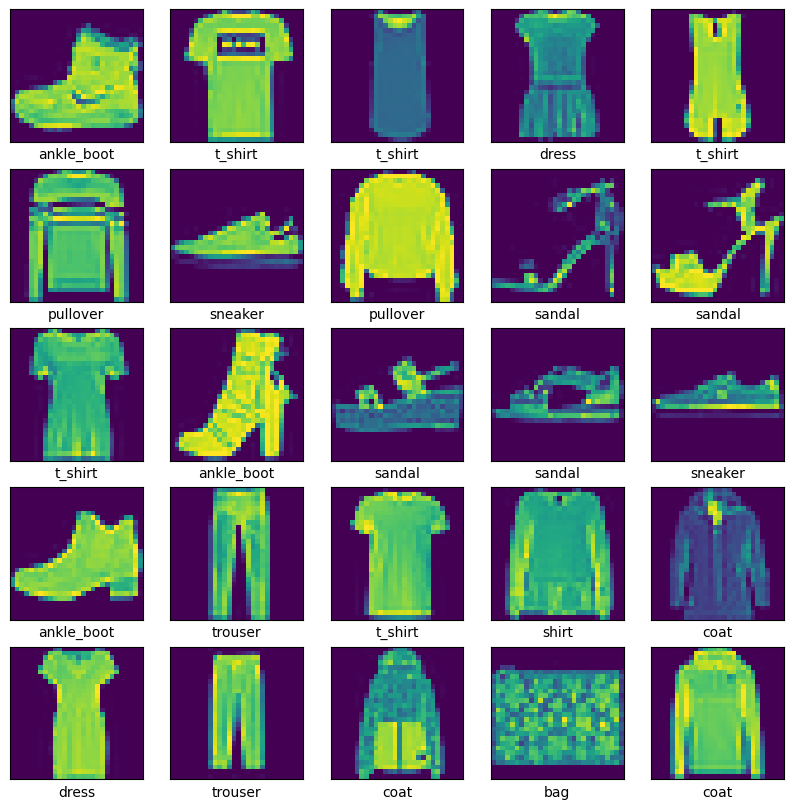

In [ ]:
# Visualizamos una muestra de 25 imágenes del conjunto de entrenamiento
# Esto nos permite verificar visualmente que las imágenes coincidan con sus etiquetas
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i]])
plt.show()


In [ ]:
# Definimos los callbacks que se utilizarán durante el entrenamiento del modelo

# Callback para guardar automáticamente el mejor modelo
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='logs/model/best_model.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min',
    save_freq='epoch'
)

# Callback para detener el entrenamiento si la pérdida de validación deja de mejorar
earlystopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.01,
    patience=3
)


In [ ]:
# Definimos la arquitectura del modelo usando la API Secuencial de Keras
model = tf.keras.models.Sequential([
    # Capa de entrada para imágenes de 28x28 con un solo canal (escala de grises)
    tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),

    # Primera capa convolucional: extrae características con 64 filtros de 3x3
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'),

    # Capa de agrupamiento: reduce ligeramente las dimensiones y resalta las características más importantes
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(1, 1)),

    # Segunda capa convolucional: extrae más características con 32 filtros
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation='relu'),

    # Segunda capa de agrupamiento: continúa reduciendo dimensionalidad conservando información relevante
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(1, 1)),

    # Flatten: convierte el tensor 3D en un vector 1D para conectar con las capas densas
    tf.keras.layers.Flatten(),

    # Capa densa completamente conectada con 128 neuronas y activación ReLU
    tf.keras.layers.Dense(units=128, activation='relu'),

    # Dropout: evita el sobreajuste desactivando el 15% de las neuronas aleatoriamente
    tf.keras.layers.Dropout(rate=0.15),

    # Capa densa intermedia con 64 neuronas
    tf.keras.layers.Dense(units=64, activation='relu'),

    # Capa de salida con tantas neuronas como clases y activación softmax para clasificación multiclase
    tf.keras.layers.Dense(units=len(class_names), activation='softmax')
])

# Compilamos el modelo definiendo la función de pérdida, el optimizador y las métricas a evaluar
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

# Mostramos un resumen de la arquitectura del modelo
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 23, 23, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 22, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 15488)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │       1,982,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,010,602 (7.67 MB)

 Trainable params: 2,010,602 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamos el modelo con los datos de entrenamiento
# Se entrenará por hasta 100 épocas, pero podría detenerse antes si el callback EarlyStopping se activa
model.fit(
    train_images,             # Imágenes de entrenamiento
    train_labels,             # Etiquetas correspondientes
    epochs=100,               # Número máximo de epocks
    batch_size=128,
    validation_split=0.2,     # Se reserva el 20% de los datos de entrenamiento para validación
    callbacks=[checkpoint_callback, earlystopping_callback]  # Callbacks para detener si no mejora
)


Epoch 1/100
368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7294 - loss: 0.7463
Epoch 1: val_loss improved from inf to 0.33107, saving model to logs/model/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7312 - loss: 0.7414 - val_accuracy: 0.8802 - val_loss: 0.3311
Epoch 2/100
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8757 - loss: 0.3361
Epoch 2: val_loss improved from 0.33107 to 0.27713, saving model to logs/model/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8758 - loss: 0.3359 - val_accuracy: 0.8989 - val_loss: 0.2771
Epoch 3/100
369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8986 - loss: 0.2702
Epoch 3: val_loss improved from 0.27713 to 0.24832, saving model to logs/model/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8987 - loss: 0.2702 - val_accuracy: 0.9099 - val_loss: 0.2483
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9118 - loss: 0.2357
Epoch 4: val_los

In [ ]:
# Evaluamos el modelo
model.evaluate(x=test_images, y=test_labels, batch_size=128)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2635


[0.2574723958969116, 0.9182000160217285]

In [ ]:
# Declaramos la funcion que se encarga de imprimir la matriz de confusion y la llamamos
def plot_confusion_matrix(labels, predictions):
  figure = plt.figure(figsize=(12, 12))
  sns.heatmap(confusion_matrix(labels=labels, predictions=predictions), annot=True,cmap=plt.cm.Blues)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


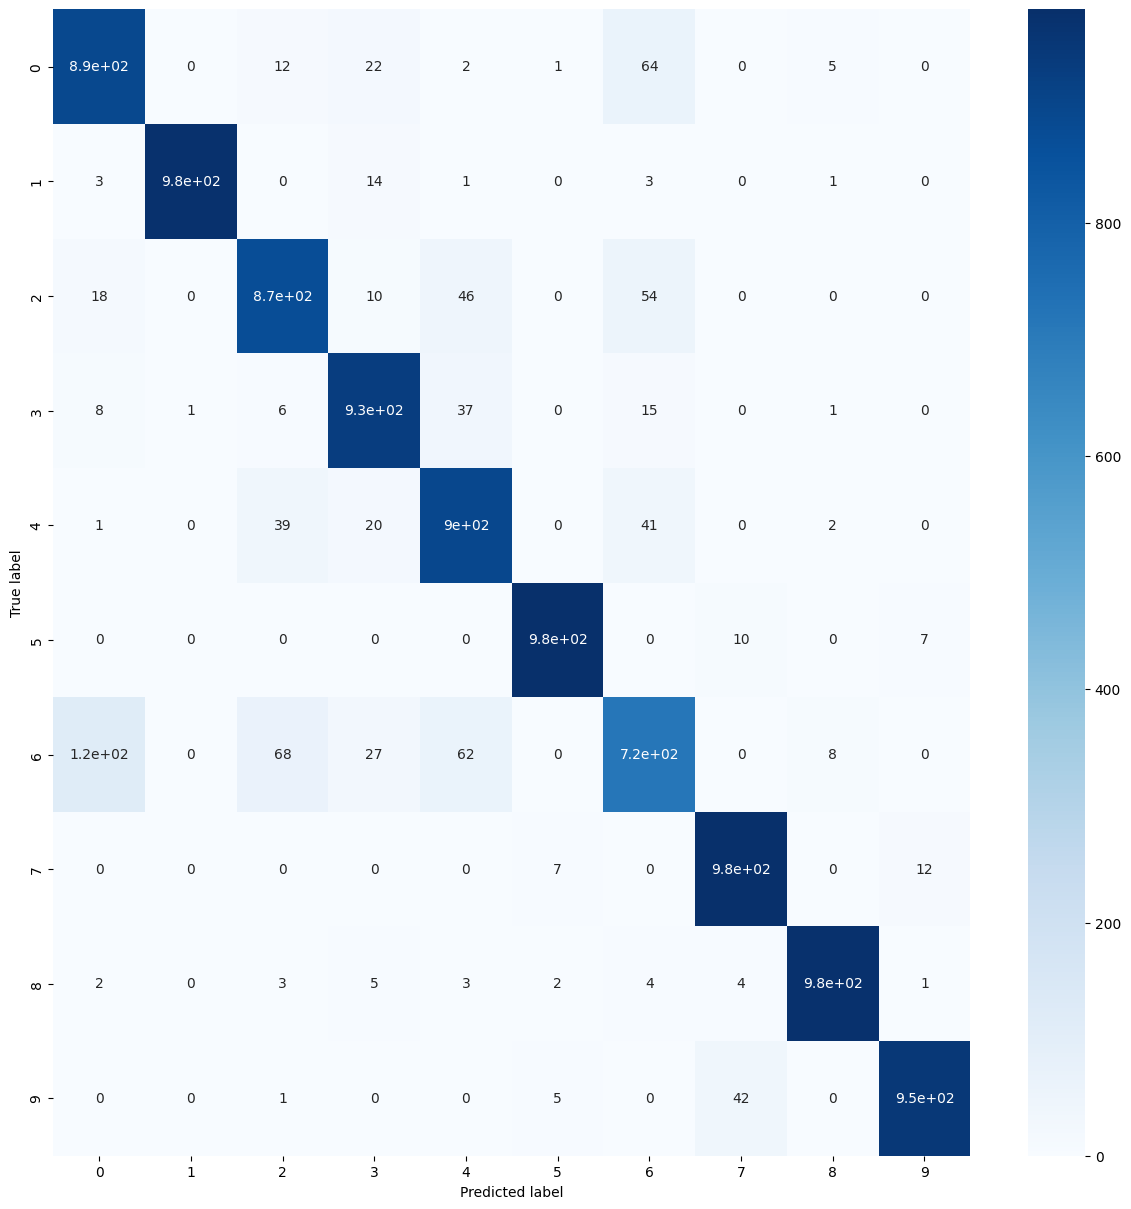

In [ ]:
# Obtenemos las predicciones obtenidas por el modelo para llenar la matriz
predictions = model.predict(x=test_images)
predictions = list(map(lambda x: np.argmax(x), predictions))

# Imprimimos la matriz de confusion
plot_confusion_matrix(labels=test_labels, predictions=predictions)

# READ ME

When you are finished with your laboratory, remember to share it. Make the URL public for Galileo.edu domain or for everyone.
Also, remember to hit Ctrl+S to save your progress.